In [1]:
# Import necessary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from collections import Counter
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchaudio
from torchaudio.transforms import MelSpectrogram, AmplitudeToDB
import warnings
warnings.filterwarnings("ignore")

# 1. Setup paths

In [2]:
# Change this to match your Kaggle dataset folder name
DATASET_FOLDER = "/kaggle/input/emo-ta/TamilSER-DB"  # Example: replace with your actual dataset name, e.g., "/kaggle/input/emota-dataset"
# Or list all inputs if unsure
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames[:5]:
#         print(os.path.join(dirname, filename))

audio_dir = DATASET_FOLDER  # All .wav files are directly here

files = [f for f in os.listdir(audio_dir) if f.endswith(".wav")]
print(f"Total audio files found: {len(files)}")

Total audio files found: 936


# 2. Parse labels from filenames

In [3]:
# Filename format: <spkID>_<senID>_<emo[:3]>.wav
# emo codes: ang=angry, hap=happy, sad=sad, fea=fear, neu=neutral

emo_map = {
    "ang": "angry",
    "hap": "happy",
    "sad": "sad",
    "fea": "fear",
    "neu": "neutral"
}

data = []
for f in files:
    parts = f.replace(".wav", "").split("_")
    if len(parts) != 3:
        print(f"Skipping irregular filename: {f}")
        continue
    spk_id = parts[0]
    sen_id = parts[1]
    emo_code = parts[2]
    emotion = emo_map.get(emo_code, "unknown")
    if emotion == "unknown":
        print(f"Unknown emotion code in {f}")
    data.append({"filename": f, "speaker_id": spk_id, "emotion": emotion})

df = pd.DataFrame(data)
print(df.head())

        filename speaker_id  emotion
0  11_14_sad.wav         11      sad
1  04_04_sad.wav         04      sad
2  01_05_neu.wav         01  neutral
3  16_18_sad.wav         16      sad
4  21_13_fea.wav         21     fear


# 3. Exploratory Data Analysis (EDA)

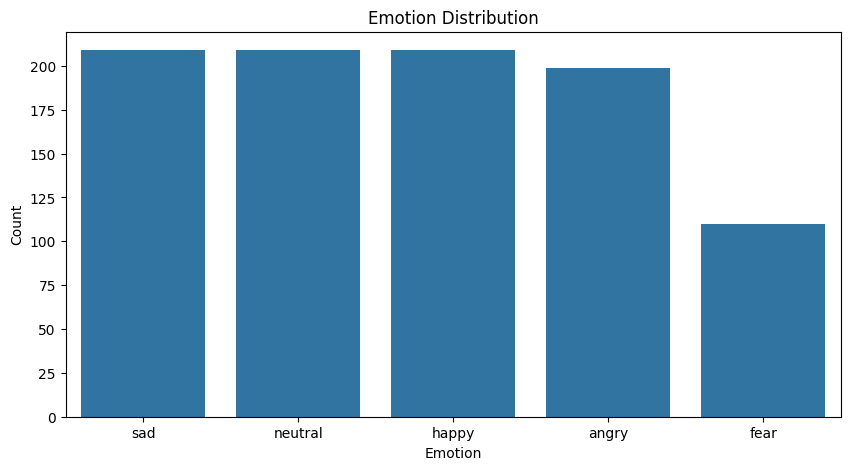

Emotion counts:
 emotion
sad        209
neutral    209
happy      209
angry      199
fear       110
Name: count, dtype: int64


In [4]:
# Emotion distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="emotion", order=df["emotion"].value_counts().index)
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

print("Emotion counts:\n", df["emotion"].value_counts())

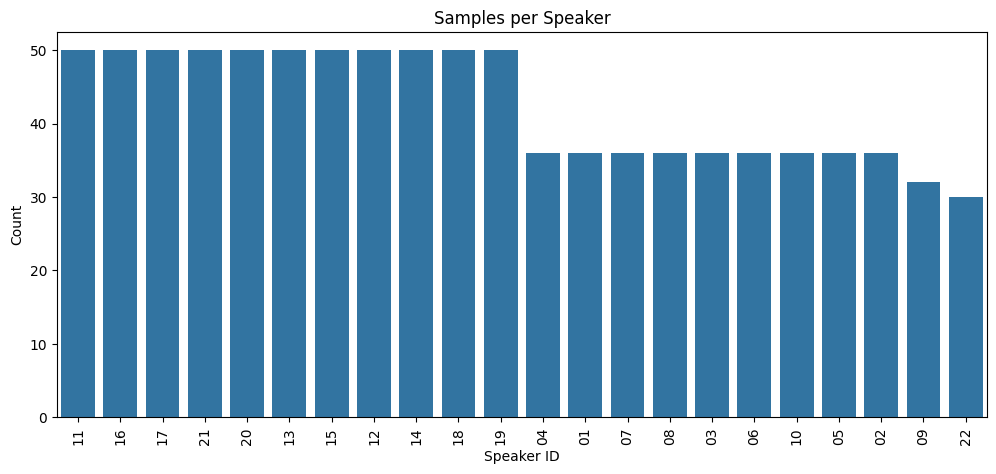

Number of unique speakers: 22


In [5]:
# Speaker distribution
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x="speaker_id", order=df["speaker_id"].value_counts().index)
plt.title("Samples per Speaker")
plt.xlabel("Speaker ID")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

print("Number of unique speakers:", df["speaker_id"].nunique())

In [6]:
# Compute durations
durations = []
sample_paths = [os.path.join(audio_dir, f) for f in df["filename"]]

for path in sample_paths:
    dur = librosa.get_duration(path=path)
    durations.append(dur)

df["duration"] = durations

print("Duration statistics:")
print(df["duration"].describe())

Duration statistics:
count    936.000000
mean       2.784571
std        0.687262
min        1.057833
25%        2.272268
50%        2.709333
75%        3.184827
max        6.400000
Name: duration, dtype: float64


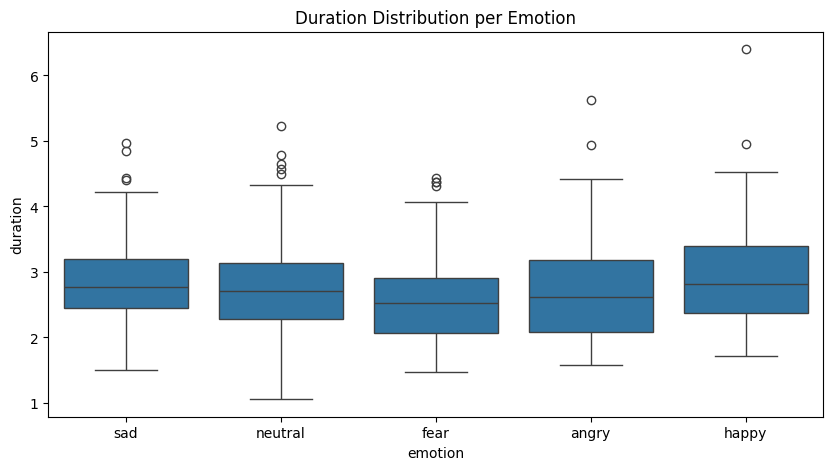

In [7]:
# Duration per emotion
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="emotion", y="duration")
plt.title("Duration Distribution per Emotion")
plt.show()

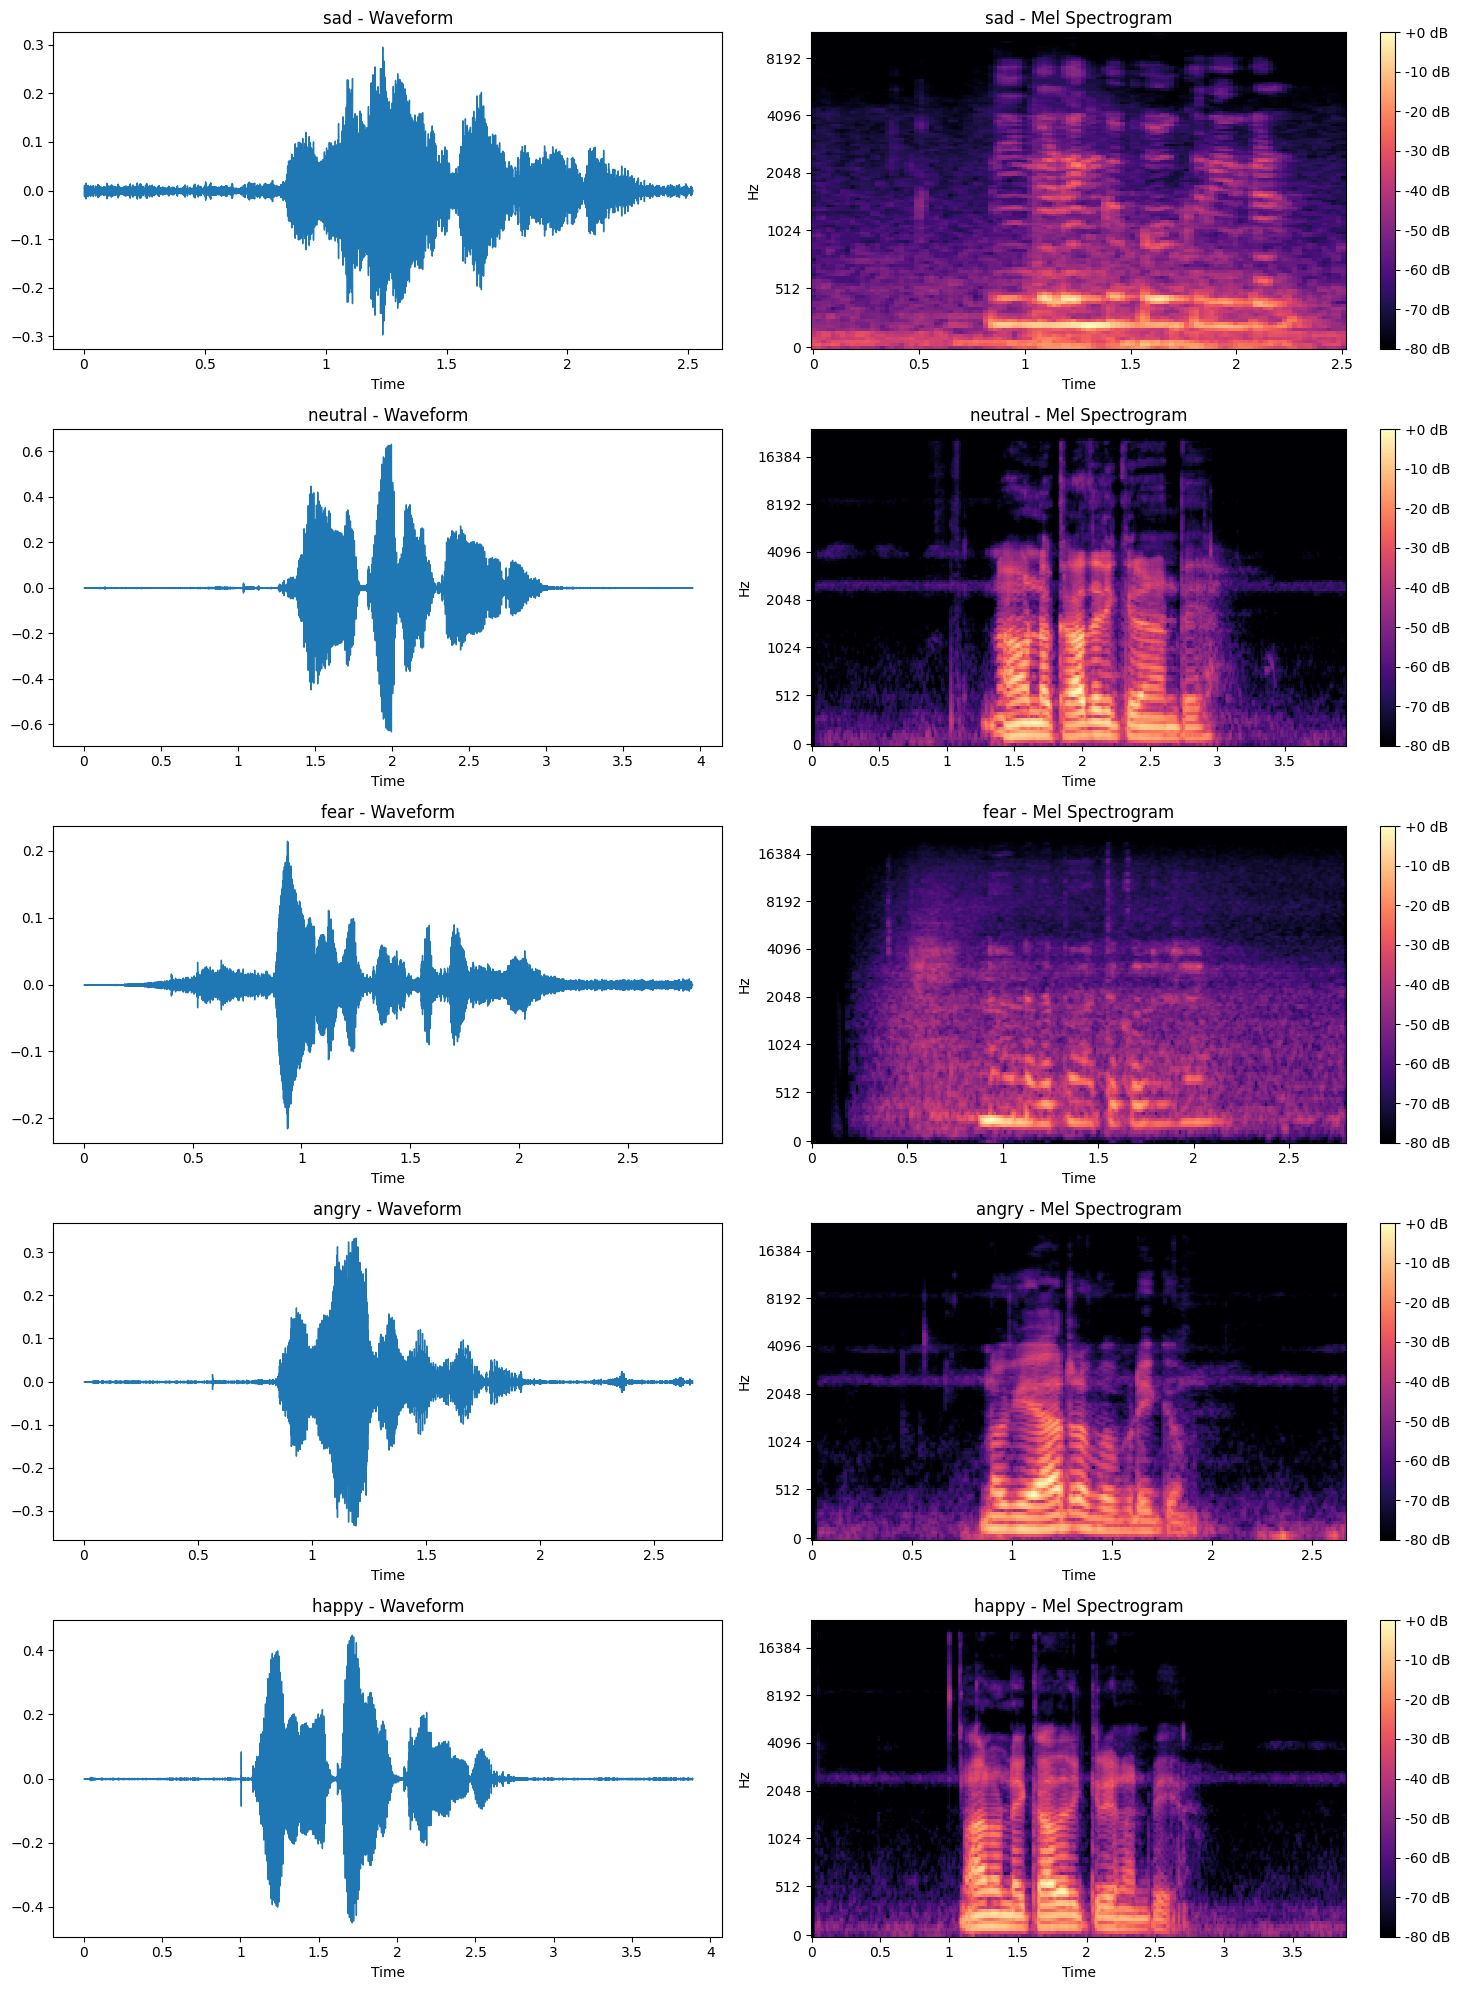

In [8]:
# Waveform and spectrogram examples (one per emotion)
emotions = df["emotion"].unique()
fig, axs = plt.subplots(len(emotions), 2, figsize=(15, 4*len(emotions)))

for idx, emo in enumerate(emotions):
    sample_file = df[df["emotion"] == emo].iloc[0]["filename"]
    path = os.path.join(audio_dir, sample_file)
    y, sr = librosa.load(path, sr=None)
    
    # Waveform
    librosa.display.waveshow(y, sr=sr, ax=axs[idx, 0])
    axs[idx, 0].set_title(f"{emo} - Waveform")
    
    # Mel spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, ax=axs[idx, 1])
    axs[idx, 1].set_title(f"{emo} - Mel Spectrogram")
    fig.colorbar(img, ax=axs[idx, 1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

# 4. Preprocessing: Log-Mel Spectrogram Extraction

In [9]:
# Parameters (tune as needed)
SAMPLE_RATE = 22050  # Common for speech; change if your files differ
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512
FIXED_LENGTH_SEC = 4  # Pad/truncate to 4 seconds (adjust based on your durations)

mel_transform = MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS
)
db_transform = AmplitudeToDB()

class EmoTaDataset(Dataset):
    def __init__(self, df, audio_dir, transform=None):
        self.df = df
        self.audio_dir = audio_dir
        self.transform = transform
        self.label_to_idx = {label: idx for idx, label in enumerate(sorted(df["emotion"].unique()))}
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = os.path.join(self.audio_dir, row["filename"])
        waveform, sr = torchaudio.load(path)
        
        # Resample if needed
        if sr != SAMPLE_RATE:
            resampler = torchaudio.transforms.Resample(sr, SAMPLE_RATE)
            waveform = resampler(waveform)
        
        waveform = waveform.mean(dim=0)  # Convert to mono if stereo
        
        # Fixed length
        target_samples = SAMPLE_RATE * FIXED_LENGTH_SEC
        if waveform.shape[0] > target_samples:
            waveform = waveform[:target_samples]
        else:
            waveform = torch.nn.functional.pad(waveform, (0, target_samples - waveform.shape[0]))
        
        # Mel spectrogram
        mel = mel_transform(waveform)  # (n_mels, time)
        mel_db = db_transform(mel)     # Log scale
        
        label = self.label_to_idx[row["emotion"]]
        
        return mel_db, label

# Create dataset
full_dataset = EmoTaDataset(df, audio_dir)

# Train/val split (80/20, stratified if possible)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

# Test loading one batch
features, labels = next(iter(train_loader))
print("Batch feature shape:", features.shape)  # e.g., (batch, n_mels, time)
print("Batch labels shape:", labels.shape)

Train samples: 748, Val samples: 188
Batch feature shape: torch.Size([32, 128, 173])
Batch labels shape: torch.Size([32])
